# **MedGemma-4B**

In this notebook, I build a deep learning pipeline to classify retinal OCT images into three categories: AMD, DME, and Normal, leveraging the vision encoder of a large multimodal model (MedGemma-4B). I walk through the full workflow, including patient-aware splitting, feature extraction using the frozen vision tower of MedGemma, training a custom multi-layer perceptron (MLP) classifier head, and finally evaluating the model's robustness through Out-Of-Distribution (OOD) detection on unseen Glaucoma images using Temperature Scaling calibration.

## **0. Input Libraries**

In [1]:
!pip install -q transformers bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 34.0 MB/s eta 0:00:00:00:0100:01


In [2]:
# Standard library
import os, glob, random, warnings, gc
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import json as _json

# Data
import numpy as np
import pandas as pd
import scipy
import scipy.stats
from PIL import Image
from tqdm import tqdm

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Scikit-learn: models and preprocessing
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample
from sklearn.calibration import calibration_curve

# Scikit-learn: metrics
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve, 
    auc
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Transformers and Hugging Face
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig
)
from huggingface_hub import login

# Kaggle
from kaggle_secrets import UserSecretsClient

# Configurations
warnings.filterwarnings('ignore')

In [3]:
SEED        = 42
MODEL_ID    = 'google/medgemma-4b-it'

BATCH_SIZE  = 256
LR          = 3e-4
EPOCHS      = 80
PATIENCE    = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## **1. HuggingFace Authentication**
MedGemma-4B is a gated model on the Hugging Face Hub, so it requires accepting the
model license and authenticating with a personal access token. The token is read
from Kaggle Secrets (`HF_TOKEN`) rather than hardcoded, so it never appears in this
notebook.

In [4]:
user_secrets = UserSecretsClient()
token = user_secrets.get_secret("HF_TOKEN")

login(token=token)

## **2. Data Loading**
Scan the OCT image paths on Kaggle, filter to valid B-scans, and build a
patient-level DataFrame with class labels.

In [5]:
DATASET_DIR = '/kaggle/input/datasets/susannamazzocchi/rasti-images/rasti_images'
SAVE_DIR    = '/kaggle/working'

In [6]:
imgs = glob.glob(DATASET_DIR + '/**/*.*', recursive=True)
imgs = [f for f in imgs if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff'))]
print(f'Total images found: {len(imgs)}')

Total images found: 3348


In [7]:
def is_valid_oct(path):
    try:
        with Image.open(path) as img:
            return img.size == (496, 512)
    except:
        return False

imgs_raw = glob.glob(DATASET_DIR + '/**/*.*', recursive=True)
imgs_raw = [f for f in imgs_raw if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff'))]

with ThreadPoolExecutor(max_workers=8) as executor:
    mask = list(executor.map(is_valid_oct, imgs_raw))

imgs = [p for p, ok in zip(imgs_raw, mask) if ok]
print(f'Total: {len(imgs_raw)}  →  After filtering: {len(imgs)}')

Total: 3348  →  After filtering: 3231


In [8]:
LABEL_MAP = {
    'AMD Part1': 'AMD', 'AMD Part2': 'AMD',
    'DME':       'DME',
    'Normal Part1': 'Normal', 'Normal Part2': 'Normal',
}

rows = []
base = Path(DATASET_DIR)
for path in imgs:
    p = Path(path)
    parts = p.relative_to(base).parts
    if len(parts) < 4:
        continue
    raw_label  = parts[0]
    patient_id = parts[2]
    label      = LABEL_MAP.get(raw_label)
    if label is None:
        continue
    rows.append({'path': path, 'label_clean': label, 'patient_id': patient_id})

df = pd.DataFrame(rows)

class_names  = sorted(df['label_clean'].unique())
CLASS_MAP    = {c: i for i, c in enumerate(class_names)}
df['label_idx'] = df['label_clean'].map(CLASS_MAP)

print(f'Samples: {len(df)}  |  Classes: {class_names}')
print(df['label_clean'].value_counts())

Samples: 3231  |  Classes: ['AMD', 'DME', 'Normal']
label_clean
Normal    1628
DME       1117
AMD        486
Name: count, dtype: int64


## **3. Patient-Level Data Splitting**
StratifiedGroupKFold (seed=42) mirrors the main notebook split exactly — no
patient appears in more than one subset.

In [9]:
y = df['label_idx'].values

sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
train_idx, temp_idx = next(sgkf.split(df, y, df['patient_id']))

df_temp  = df.iloc[temp_idx].reset_index(drop=True)
y_temp   = df_temp['label_idx'].values

sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=SEED)
val_idx, test_idx = next(sgkf2.split(df_temp, y_temp, df_temp['patient_id']))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val   = df_temp.iloc[val_idx].reset_index(drop=True)
df_test  = df_temp.iloc[test_idx].reset_index(drop=True)

for name, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    n_pat = d['patient_id'].nunique()
    print(f'{name:6s}  {len(d):5d} images  {n_pat:3d} patients')

Train    2149 images   79 patients
Val       571 images   19 patients
Test      511 images   19 patients


## **4. Load MedGemma-4B**
Loaded in float16 for inference; only the vision tower is kept afterward, so
the language model weights are never used.

In [10]:
processor = AutoProcessor.from_pretrained(MODEL_ID)

mg_model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map='auto',
)
mg_model.eval()
print('MedGemma loaded')

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

MedGemma loaded


In [11]:
vision_tower    = mg_model.model.vision_tower
image_processor = processor.image_processor

del mg_model.model.language_model
del mg_model.model.multi_modal_projector
gc.collect()
torch.cuda.empty_cache()

vision_tower.eval()
DEVICE = next(vision_tower.parameters()).device
print(f"Vision tower on: {DEVICE}")
print(f"Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

Vision tower on: cuda:0
Free VRAM: 11.2 GB


In [12]:
vision_tower.eval()
dummy_pil = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
dummy_inp = image_processor(images=dummy_pil, return_tensors='pt')['pixel_values']  
with torch.no_grad():
    dummy_out = vision_tower(dummy_inp)

if hasattr(dummy_out, 'pooler_output') and dummy_out.pooler_output is not None:
    FEAT_DIM   = dummy_out.pooler_output.shape[-1]
    USE_POOLER = True
else:
    FEAT_DIM   = dummy_out.last_hidden_state.shape[-1]
    USE_POOLER = False

print(f'Feature dimension: {FEAT_DIM}  |  pooler_output: {USE_POOLER}')

Feature dimension: 1152  |  pooler_output: False


## **5. Feature Extraction Dataset**
Minimal Dataset returning PIL RGB images: the processor handles all resizing
and normalization internally.

In [13]:
class RawImageDataset(Dataset):
    def __init__(self, df):
        self.paths  = df['path'].tolist()
        self.labels = df['label_idx'].tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return img, self.labels[idx]

## **6. Extract & Cache Features**
Single forward pass through the vision encoder for every split. Features are
stored in CPU RAM: training runs entirely without the large model.

In [14]:
def extract_features(df, split_name, batch_size=1):
    dataset = RawImageDataset(df)
    all_feats, all_labels = [], []
    n = len(dataset)
    for start in range(0, n, batch_size):
        batch_imgs, batch_lbls = [], []
        for i in range(start, min(start + batch_size, n)):
            img, lbl = dataset[i]
            batch_imgs.append(img)
            batch_lbls.append(lbl)
        inputs = image_processor(images=batch_imgs, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            vision_out = vision_tower(inputs['pixel_values'])
            feat = vision_out.pooler_output if USE_POOLER else vision_out.last_hidden_state.mean(dim=1)
        all_feats.append(feat.float().cpu())
        all_labels.extend(batch_lbls)
        if (start // batch_size) % 100 == 0:
            print(f'{split_name}: {start}/{n}', flush=True)
    print(f'{split_name}: done — {n} images', flush=True)
    return torch.cat(all_feats, dim=0), torch.tensor(all_labels, dtype=torch.long)

print("Starting...", flush=True)
feats_train, labels_train = extract_features(df_train, 'Train')
feats_val,   labels_val   = extract_features(df_val,   'Val  ')
feats_test,  labels_test  = extract_features(df_test,  'Test ')
print(f'Train: {feats_train.shape}  Val: {feats_val.shape}  Test: {feats_test.shape}')

Starting...
Train: 0/2149
Train: 100/2149
Train: 200/2149
Train: 300/2149
Train: 400/2149
Train: 500/2149
Train: 600/2149
Train: 700/2149
Train: 800/2149
Train: 900/2149
Train: 1000/2149
Train: 1100/2149
Train: 1200/2149
Train: 1300/2149
Train: 1400/2149
Train: 1500/2149
Train: 1600/2149
Train: 1700/2149
Train: 1800/2149
Train: 1900/2149
Train: 2000/2149
Train: 2100/2149
Train: done — 2149 images
Val  : 0/571
Val  : 100/571
Val  : 200/571
Val  : 300/571
Val  : 400/571
Val  : 500/571
Val  : done — 571 images
Test : 0/511
Test : 100/511
Test : 200/511
Test : 300/511
Test : 400/511
Test : 500/511
Test : done — 511 images
Train: torch.Size([2149, 1152])  Val: torch.Size([571, 1152])  Test: torch.Size([511, 1152])


## **7. Classifier Head**
Two-layer MLP with LayerNorm, GELU, and dropout. Operates purely on frozen
MedGemma features.

In [15]:
class OCTClassifier(nn.Module):
    def __init__(self, in_dim, num_classes=3, hidden=512, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.net(x)


classifier = OCTClassifier(FEAT_DIM, num_classes=len(class_names)).to(DEVICE)
print(f'Classifier params: {sum(p.numel() for p in classifier.parameters()):,}')

Classifier params: 592,899


## **8. Class Weights & DataLoaders**
Inverse-frequency class weights compensate for AMD underrepresentation.
Training DataLoader shuffled; val/test not shuffled.

In [16]:
counts   = torch.bincount(labels_train)
weights  = labels_train.shape[0] / (len(class_names) * counts.float())
weights  = weights.to(DEVICE)
print('Class weights:', {c: round(w.item(), 3) for c, w in zip(class_names, weights)})

criterion = nn.CrossEntropyLoss(weight=weights)

Class weights: {'AMD': 2.663, 'DME': 0.852, 'Normal': 0.689}


In [17]:
ds_train = TensorDataset(feats_train, labels_train)
ds_val   = TensorDataset(feats_val,   labels_val)
ds_test  = TensorDataset(feats_test,  labels_test)

loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False)
loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False)

## **9. Training Loop**
The classifier head is trained from scratch on the cached MedGemma features
(the vision encoder stays frozen). Adam optimizer with ReduceLROnPlateau and
early stopping on validation loss, up to 80 epochs.

In [18]:
optimizer = torch.optim.Adam(classifier.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

In [19]:
def run_epoch(loader, train=True):
    classifier.train() if train else classifier.eval()
    total_loss, correct, n = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for feats, labels in loader:
            feats, labels = feats.to(DEVICE), labels.to(DEVICE)
            logits = classifier(feats)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * feats.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            n          += feats.size(0)
    return total_loss / n, correct / n

In [20]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
best_state    = None
patience_cnt  = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(loader_train, train=True)
    vl_loss, vl_acc = run_epoch(loader_val,   train=False)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    flag = ''
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state    = {k: v.cpu().clone() for k, v in classifier.state_dict().items()}
        patience_cnt  = 0
        flag          = '  ✔ best'
    else:
        patience_cnt += 1

    print(f'Ep {epoch:03d}  tr_loss={tr_loss:.4f}  vl_loss={vl_loss:.4f}  '
          f'tr_acc={tr_acc:.3f}  vl_acc={vl_acc:.3f}  '
          f'lr={optimizer.param_groups[0]["lr"]:.1e}{flag}')

    if patience_cnt >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

classifier.load_state_dict(best_state)
print(f'\nBest val loss: {best_val_loss:.4f}')

Ep 001  tr_loss=1.0999  vl_loss=0.9960  tr_acc=0.410  vl_acc=0.713  lr=3.0e-04  ✔ best
Ep 002  tr_loss=0.9778  vl_loss=0.9786  tr_acc=0.519  vl_acc=0.653  lr=3.0e-04  ✔ best
Ep 003  tr_loss=0.8651  vl_loss=0.8321  tr_acc=0.704  vl_acc=0.771  lr=3.0e-04  ✔ best
Ep 004  tr_loss=0.7153  vl_loss=0.6737  tr_acc=0.747  vl_acc=0.588  lr=3.0e-04  ✔ best
Ep 005  tr_loss=0.5816  vl_loss=0.6340  tr_acc=0.775  vl_acc=0.762  lr=3.0e-04  ✔ best
Ep 006  tr_loss=0.4690  vl_loss=0.4905  tr_acc=0.819  vl_acc=0.790  lr=3.0e-04  ✔ best
Ep 007  tr_loss=0.3728  vl_loss=0.4819  tr_acc=0.852  vl_acc=0.823  lr=3.0e-04  ✔ best
Ep 008  tr_loss=0.3288  vl_loss=0.6821  tr_acc=0.866  vl_acc=0.835  lr=3.0e-04
Ep 009  tr_loss=0.2881  vl_loss=0.5088  tr_acc=0.895  vl_acc=0.792  lr=3.0e-04
Ep 010  tr_loss=0.2316  vl_loss=0.6723  tr_acc=0.908  vl_acc=0.825  lr=3.0e-04
Ep 011  tr_loss=0.2056  vl_loss=0.6944  tr_acc=0.919  vl_acc=0.830  lr=3.0e-04
Ep 012  tr_loss=0.1926  vl_loss=0.7076  tr_acc=0.921  vl_acc=0.853  lr=3.0e

## **10. Training Curves**
Loss and accuracy over epochs for visual inspection of convergence and
overfitting.

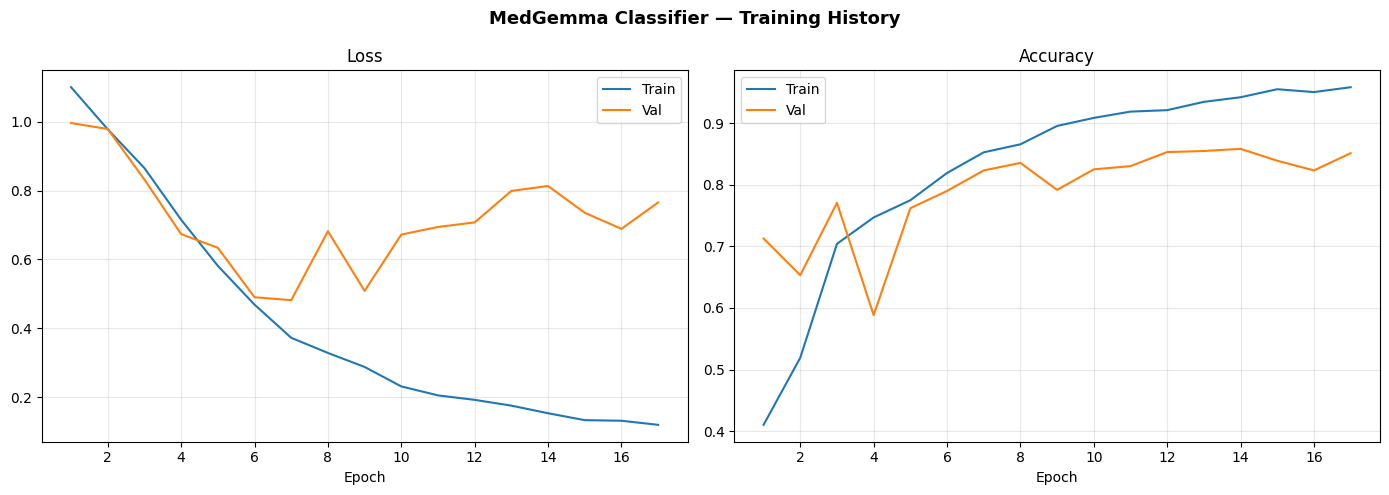

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MedGemma Classifier — Training History', fontsize=13, fontweight='bold')

epochs_ran = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_ran, history['train_loss'], label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## **11. Evaluation on Test Set**
Confusion matrix, per-class metrics, ROC curves, and macro-AUC.

In [22]:
classifier.eval()
all_preds, all_labels_lst, all_probs = [], [], []

with torch.no_grad():
    for feats, labels in loader_test:
        feats = feats.to(DEVICE)
        logits = classifier(feats)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels_lst.extend(labels.numpy())

y_true  = np.array(all_labels_lst)
y_pred  = np.array(all_preds)
y_probs = np.vstack(all_probs)

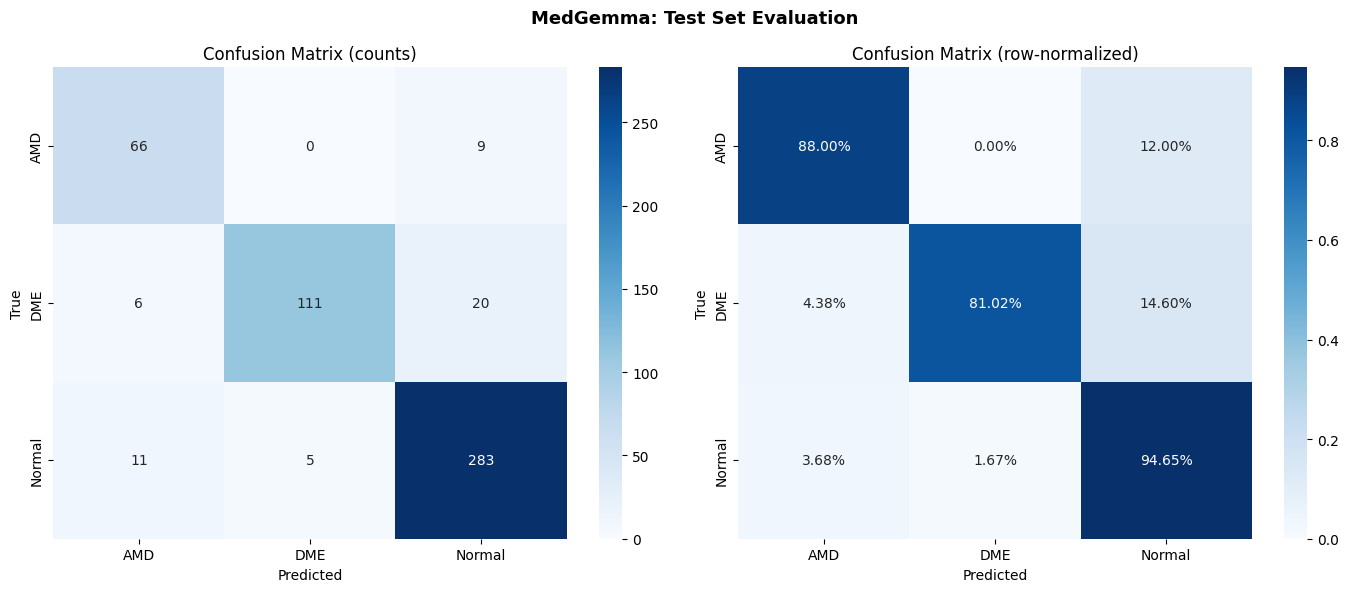

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('MedGemma: Test Set Evaluation', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (row-normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

In [24]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

         AMD     0.7952    0.8800    0.8354        75
         DME     0.9569    0.8102    0.8775       137
      Normal     0.9071    0.9465    0.9264       299

    accuracy                         0.9002       511
   macro avg     0.8864    0.8789    0.8798       511
weighted avg     0.9040    0.9002    0.8999       511



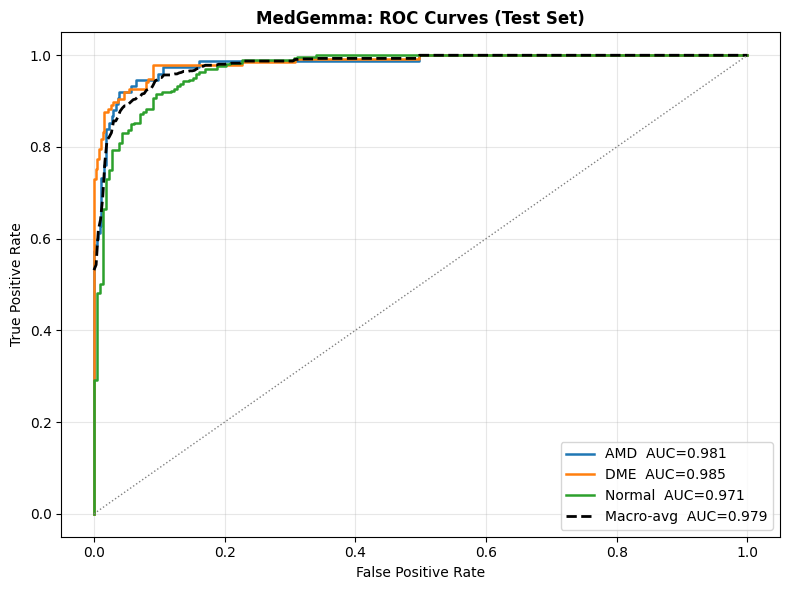

Macro-AUC: 0.9787


In [25]:
y_bin = label_binarize(y_true, classes=range(len(class_names)))

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('MedGemma: ROC Curves (Test Set)', fontweight='bold')

all_fpr  = np.linspace(0, 1, 300)
mean_tpr = np.zeros_like(all_fpr)

for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
    auc_val     = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=1.8, label=f'{cls}  AUC={auc_val:.3f}')
    mean_tpr   += np.interp(all_fpr, fpr, tpr)

mean_tpr /= len(class_names)
macro_auc = auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, 'k--', linewidth=2,
        label=f'Macro-avg  AUC={macro_auc:.3f}')
ax.plot([0, 1], [0, 1], ':', color='gray', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Macro-AUC: {macro_auc:.4f}')


## **12. Metrics Summary Table**
Per-class precision, recall, F1, support, and AUC in a single DataFrame.

In [26]:
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

rows = []
for i, cls in enumerate(class_names):
    auc_val = roc_auc_score(y_bin[:, i], y_probs[:, i])
    rows.append({
        'Class':     cls,
        'Precision': round(report[cls]['precision'], 4),
        'Recall':    round(report[cls]['recall'],    4),
        'F1-Score':  round(report[cls]['f1-score'],  4),
        'Support':   int(report[cls]['support']),
        'AUC':       round(auc_val, 4),
    })

macro = report['macro avg']
rows.append({
    'Class':     'macro avg',
    'Precision': round(macro['precision'], 4),
    'Recall':    round(macro['recall'],    4),
    'F1-Score':  round(macro['f1-score'],  4),
    'Support':   int(macro['support']),
    'AUC':       round(macro_auc, 4),
})

df_metrics = pd.DataFrame(rows)
display(df_metrics.style.highlight_max(
    subset=['Precision','Recall','F1-Score','AUC'], color='#d5f5e3'
).format(precision=4))

,Class,Precision,Recall,F1-Score,Support,AUC
0,AMD,0.7952,0.8800,0.8354,75,0.9809
1,DME,0.9569,0.8102,0.8775,137,0.9847
2,Normal,0.9071,0.9465,0.9264,299,0.9707
3,macro avg,0.8864,0.8789,0.8798,511,0.9787


In [27]:
# Bootstrap 95% CI: Accuracy and Macro-AUC

def bootstrap_ci(y_true, y_pred, y_probs, n_bootstrap=1000, ci=95):
    accs, aucs = [], []
    y_bin_bs = label_binarize(y_true, classes=range(len(class_names)))

    for _ in range(n_bootstrap):
        idx = resample(range(len(y_true)), replace=True, random_state=None)
        acc = (y_true[idx] == y_pred[idx]).mean()
        try:
            auc_val = roc_auc_score(y_bin_bs[idx], y_probs[idx],
                                    multi_class='ovr', average='macro')
        except ValueError:
            continue
        accs.append(acc)
        aucs.append(auc_val)

    alpha = (100 - ci) / 2
    return {
        'accuracy':  (np.mean(accs),
                      np.percentile(accs, alpha),
                      np.percentile(accs, 100 - alpha)),
        'macro_auc': (np.mean(aucs),
                      np.percentile(aucs, alpha),
                      np.percentile(aucs, 100 - alpha)),
    }

ci_results = bootstrap_ci(y_true, y_pred, y_probs)

print('Bootstrap 95% CI (1000 iterations): MedGemma:')
m, lo, hi = ci_results['accuracy']
print(f'  Accuracy :  {m:.3f}  [{lo:.3f}, {hi:.3f}]')
m, lo, hi = ci_results['macro_auc']
print(f'  Macro-AUC:  {m:.3f}  [{lo:.3f}, {hi:.3f}]')

Bootstrap 95% CI (1000 iterations): MedGemma:
  Accuracy :  0.900  [0.873, 0.924]
  Macro-AUC:  0.979  [0.968, 0.988]


## **13. OOD Detection — Glaucoma**
Same protocol as the main notebook: 100 unseen glaucoma OCT images, entropy
and confidence-based flagging, and temperature scaling for calibration.

In [28]:
GLAUCOMA_DIR  = '/kaggle/input/datasets/susannamazzocchi/dataset-glaucoma/glaucoma_dataset'
OOD_THRESHOLD = 0.70

glaucoma_imgs = sorted(
    glob.glob(GLAUCOMA_DIR + '/*.jpg') +
    glob.glob(GLAUCOMA_DIR + '/*.png') +
    glob.glob(GLAUCOMA_DIR + '/*.jpeg')
)
print(f'Glaucoma OOD images found: {len(glaucoma_imgs)}')

Glaucoma OOD images found: 100


In [29]:
class OODDataset(Dataset):
    def __init__(self, img_paths):
        self.paths = img_paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        return Image.open(self.paths[idx]).convert('RGB')


def extract_ood_features(img_paths, batch_size=1):
    dataset = OODDataset(img_paths)
    all_feats = []
    n = len(dataset)
    for start in range(0, n, batch_size):
        batch_imgs = [dataset[i] for i in range(start, min(start + batch_size, n))]
        inputs = image_processor(images=batch_imgs, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            vision_out = vision_tower(inputs['pixel_values'])
            feat = vision_out.pooler_output if USE_POOLER else vision_out.last_hidden_state.mean(dim=1)
        all_feats.append(feat.float().cpu())
        if (start // batch_size) % 20 == 0:
            print(f'OOD: {start}/{n}', flush=True)
    return torch.cat(all_feats, dim=0)

In [30]:
feats_ood = extract_ood_features(glaucoma_imgs)

classifier.eval()
with torch.no_grad():
    logits_ood = classifier(feats_ood.to(DEVICE))
    probs_ood  = torch.softmax(logits_ood, dim=1).cpu().numpy()

preds_ood    = probs_ood.argmax(axis=1)
max_conf_ood = probs_ood.max(axis=1)

print(f'\nMedGemma — Glaucoma OOD predictions:')
for i, cls in enumerate(class_names):
    count = (preds_ood == i).sum()
    print(f'  {cls:10s}: {count:3d}  ({count/len(preds_ood)*100:.1f}%)')
print(f'  Mean max confidence : {max_conf_ood.mean():.3f}')
print(f'  Flagged uncertain   : {(max_conf_ood < OOD_THRESHOLD).sum()}/{len(preds_ood)} [threshold={OOD_THRESHOLD}]')

OOD: 0/100
OOD: 20/100
OOD: 40/100
OOD: 60/100
OOD: 80/100

MedGemma — Glaucoma OOD predictions:
  AMD       : 100  (100.0%)
  DME       :   0  (0.0%)
  Normal    :   0  (0.0%)
  Mean max confidence : 0.938
  Flagged uncertain   : 7/100 [threshold=0.7]


In [31]:
# Temperature Scaling calibration 

def find_temperature(feats_val, labels_val, T_range=(0.5, 10.0), steps=200):
    best_T, best_nll = 1.0, float('inf')
    classifier.eval()
    with torch.no_grad():
        logits = classifier(feats_val.to(DEVICE))
    for T in np.linspace(T_range[0], T_range[1], steps):
        scaled = logits / T
        nll = nn.CrossEntropyLoss()(scaled, labels_val.to(DEVICE)).item()
        if nll < best_nll:
            best_nll, best_T = nll, T
    return best_T

T_opt = find_temperature(feats_val, labels_val)
print(f'Optimal temperature: {T_opt:.2f}')

Optimal temperature: 0.93


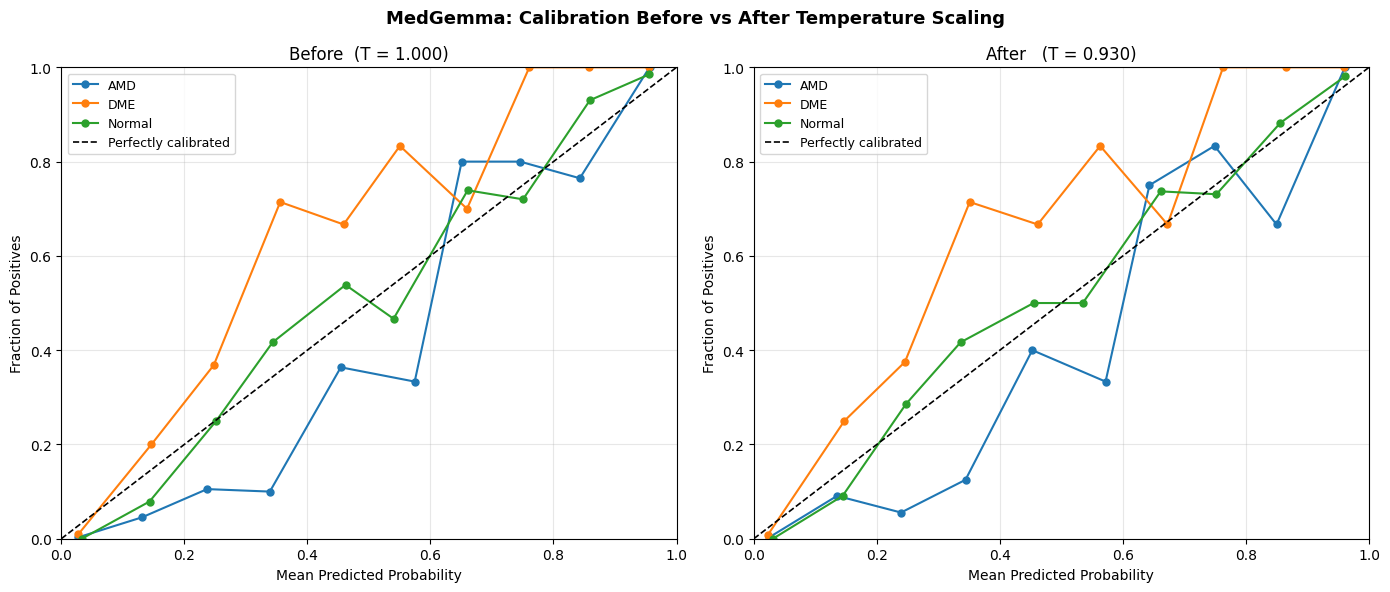

In [32]:
# Calibration Before vs After Temperature Scaling

classifier.eval()
with torch.no_grad():
    logits_test = classifier(feats_test.to(DEVICE))
    probs_test_cal = torch.softmax(logits_test / T_opt, dim=1).cpu().numpy()

with torch.no_grad():
    logits_val_cal = classifier(feats_val.to(DEVICE))
    probs_val_cal  = torch.softmax(logits_val_cal / T_opt, dim=1).cpu().numpy()
ent_val = scipy.stats.entropy(probs_val_cal, axis=1)   # in-distribution reference
y_bin_cal = label_binarize(y_true, classes=range(len(class_names)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('MedGemma: Calibration Before vs After Temperature Scaling',
             fontsize=13, fontweight='bold')

for ax, (probs, subtitle) in zip(axes, [
    (y_probs,       f'Before  (T = 1.000)'),
    (probs_test_cal, f'After   (T = {T_opt:.3f})')
]):
    for i, cls in enumerate(class_names):
        prob_true, prob_pred = calibration_curve(
            y_bin_cal[:, i], probs[:, i], n_bins=10, strategy='uniform'
        )
        ax.plot(prob_pred, prob_true, marker='o', linewidth=1.5,
                label=cls, markersize=5)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Perfectly calibrated')
    ax.set_title(subtitle)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [33]:
with torch.no_grad():
    logits_ood_raw = classifier(feats_ood.to(DEVICE))
    probs_ood_cal  = torch.softmax(logits_ood_raw / T_opt, dim=1).cpu().numpy()

max_conf_cal = probs_ood_cal.max(axis=1)

print(f'After Temperature Scaling (T={T_opt:.2f}):')
print(f'  Mean max confidence OOD : {max_conf_cal.mean():.3f}  (was {max_conf_ood.mean():.3f})')
print(f'  Flagged (thresh=0.70)   : {(max_conf_cal < 0.70).sum()}/100  (were {(max_conf_ood < 0.70).sum()}/100)')

After Temperature Scaling (T=0.93):
  Mean max confidence OOD : 0.945  (was 0.938)
  Flagged (thresh=0.70)   : 7/100  (were 7/100)


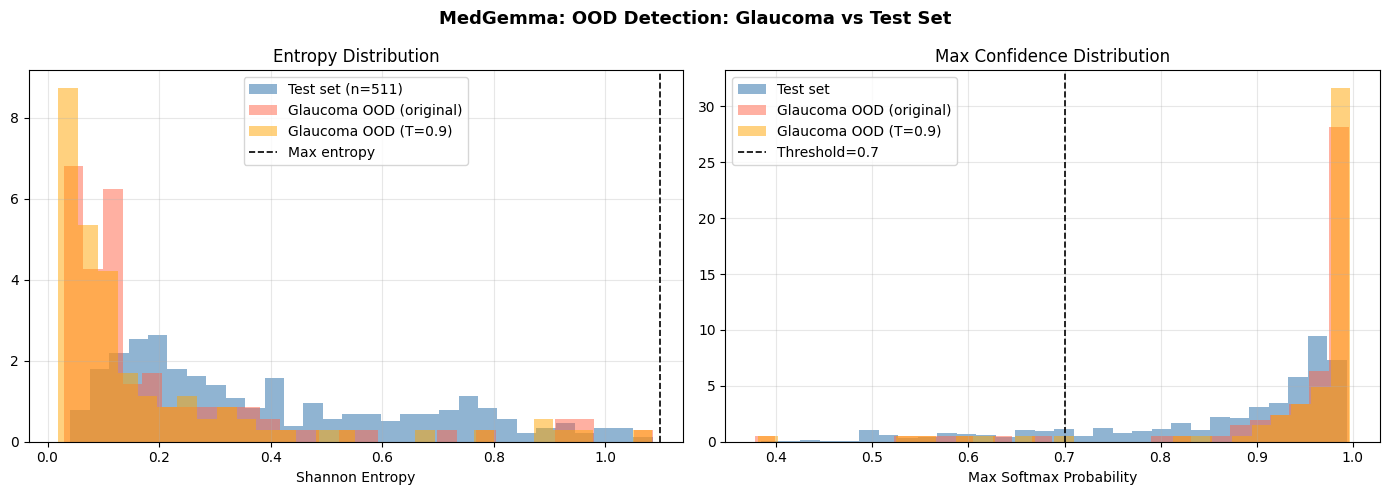


Entropy — Test set mean    : 0.396
Entropy — Glaucoma original: 0.204
Entropy — Glaucoma T=0.9   : 0.177


In [34]:
ent_ood     = scipy.stats.entropy(probs_ood,     axis=1)
ent_ood_cal = scipy.stats.entropy(probs_ood_cal, axis=1)
ent_test    = scipy.stats.entropy(y_probs,       axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MedGemma: OOD Detection: Glaucoma vs Test Set', fontsize=13, fontweight='bold')

axes[0].hist(ent_test,    bins=30, alpha=0.6, color='steelblue', density=True, label=f'Test set (n={len(ent_test)})')
axes[0].hist(ent_ood,     bins=30, alpha=0.5, color='tomato',    density=True, label=f'Glaucoma OOD (original)')
axes[0].hist(ent_ood_cal, bins=30, alpha=0.5, color='orange',    density=True, label=f'Glaucoma OOD (T={T_opt:.1f})')
axes[0].axvline(np.log(3), color='black', linestyle='--', linewidth=1.2, label='Max entropy')
axes[0].set_title('Entropy Distribution')
axes[0].set_xlabel('Shannon Entropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(y_probs.max(axis=1), bins=30, alpha=0.6, color='steelblue', density=True, label='Test set')
axes[1].hist(max_conf_ood,        bins=30, alpha=0.5, color='tomato',    density=True, label='Glaucoma OOD (original)')
axes[1].hist(max_conf_cal,        bins=30, alpha=0.5, color='orange',    density=True, label=f'Glaucoma OOD (T={T_opt:.1f})')
axes[1].axvline(OOD_THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold={OOD_THRESHOLD}')
axes[1].set_title('Max Confidence Distribution')
axes[1].set_xlabel('Max Softmax Probability')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nEntropy — Test set mean    : {ent_test.mean():.3f}')
print(f'Entropy — Glaucoma original: {ent_ood.mean():.3f}')
print(f'Entropy — Glaucoma T={T_opt:.1f}   : {ent_ood_cal.mean():.3f}')

In [35]:
for thresh in [0.60, 0.70, 0.80, 0.90]:
    orig_flagged = (max_conf_ood < thresh).sum()
    cal_flagged  = (max_conf_cal < thresh).sum()
    print(f'conf < {thresh:.2f}  |  original: {orig_flagged:3d}/100  |  calibrated (T={T_opt:.1f}): {cal_flagged:3d}/100')

conf < 0.60  |  original:   5/100  |  calibrated (T=0.9):   4/100
conf < 0.70  |  original:   7/100  |  calibrated (T=0.9):   7/100
conf < 0.80  |  original:   7/100  |  calibrated (T=0.9):   7/100
conf < 0.90  |  original:  13/100  |  calibrated (T=0.9):  11/100


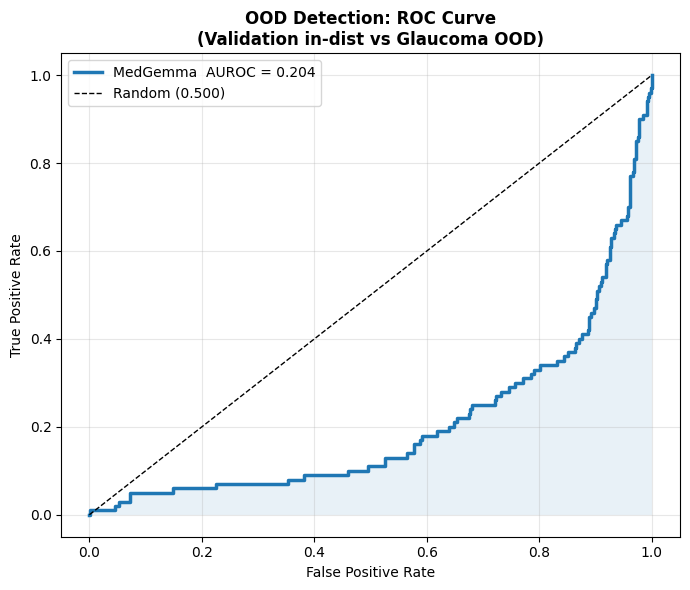


═════════════════════════════════════════════
        OOD DETECTION AUROC: MedGemma        
═════════════════════════════════════════════
  In-dist reference : validation set  (n=571)
  OOD               : glaucoma        (n=100)
  Temperature T     : 0.930
  AUROC             : 0.204
═════════════════════════════════════════════


In [36]:
# OOD Detection AUROC
scores_auroc = np.concatenate([ent_val, ent_ood_cal])
labels_auroc = np.concatenate([np.zeros(len(ent_val)), np.ones(len(ent_ood_cal))])

fpr, tpr, _ = roc_curve(labels_auroc, scores_auroc)
auroc        = roc_auc_score(labels_auroc, scores_auroc)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, linewidth=2.5, label=f'MedGemma  AUROC = {auroc:.3f}')
ax.fill_between(fpr, tpr, alpha=0.10)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (0.500)')
ax.set_title('OOD Detection: ROC Curve\n(Validation in-dist vs Glaucoma OOD)',
             fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n{"═"*45}')
print(f'{"OOD DETECTION AUROC: MedGemma":^45}')
print(f'{"═"*45}')
print(f'  In-dist reference : validation set  (n={len(ent_val)})')
print(f'  OOD               : glaucoma        (n={len(ent_ood_cal)})')
print(f'  Temperature T     : {T_opt:.3f}')
print(f'  AUROC             : {auroc:.3f}')
print(f'{"═"*45}')

## **14. Exporting Models and Configuration for GUI Deployment**

In [37]:
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(classifier.state_dict(), f'{SAVE_DIR}/best_MedGemma.pth')

config = {
    'model_id':    MODEL_ID,
    'feat_dim':    FEAT_DIM,
    'use_pooler':  USE_POOLER,
    'class_names': class_names,
    'class_map':   CLASS_MAP,
    'hidden_dim':  512,
    'dropout':     0.3,
    'test_acc':    float((y_true == y_pred).mean()),
    'macro_auc':   float(macro_auc),
}

with open(f'{SAVE_DIR}/medgemma_config.json', 'w') as f:
    _json.dump(config, f, indent=2)

print('Saved:')
print(f'  {SAVE_DIR}/best_MedGemma.pth')
print(f'  {SAVE_DIR}/medgemma_config.json')
print(f'  Test accuracy : {config["test_acc"]:.4f}')
print(f'  Macro-AUC     : {config["macro_auc"]:.4f}\n')

PRED_DIR_MG = f"{SAVE_DIR}/predictions"
os.makedirs(PRED_DIR_MG, exist_ok=True)

np.save(f"{PRED_DIR_MG}/MedGemma_y_true.npy",  y_true)
np.save(f"{PRED_DIR_MG}/MedGemma_y_pred.npy",  y_pred)
np.save(f"{PRED_DIR_MG}/MedGemma_y_probs.npy", y_probs)

classifier.eval()
with torch.no_grad():
    logits_test = classifier(feats_test.to(DEVICE))
    probs_test_cal = torch.softmax(logits_test / T_opt, dim=1).cpu().numpy()
np.save(f"{PRED_DIR_MG}/MedGemma_y_probs_cal.npy", probs_test_cal)

with torch.no_grad():
    logits_val_cal = classifier(feats_val.to(DEVICE))
    probs_val_cal  = torch.softmax(logits_val_cal / T_opt, dim=1).cpu().numpy()
    
    logits_ood_raw = classifier(feats_ood.to(DEVICE))
    probs_ood_cal  = torch.softmax(logits_ood_raw / T_opt, dim=1).cpu().numpy()

ent_val_mg = scipy.stats.entropy(probs_val_cal, axis=1)
ent_ood_mg = scipy.stats.entropy(probs_ood_cal, axis=1)
np.save(f"{PRED_DIR_MG}/MedGemma_ent_val.npy", ent_val_mg)
np.save(f"{PRED_DIR_MG}/MedGemma_ent_ood.npy", ent_ood_mg)

meta_mg = {
    "class_names": class_names,
    "T_opt": float(T_opt),
    "test_acc": float((y_true == y_pred).mean()),
    "macro_auc": float(macro_auc),
}
with open(f"{PRED_DIR_MG}/meta.json", "w") as f:
    _json.dump(meta_mg, f, indent=2)

print(f"✔ All saved in {PRED_DIR_MG}")
for fname in sorted(os.listdir(PRED_DIR_MG)):
    size = os.path.getsize(f"{PRED_DIR_MG}/{fname}") / 1e3
    print(f"  {fname:<45} {size:6.1f} KB")

Saved:
  /kaggle/working/best_MedGemma.pth
  /kaggle/working/medgemma_config.json
  Test accuracy : 0.9002
  Macro-AUC     : 0.9787

✔ All saved in /kaggle/working/predictions
  MedGemma_ent_ood.npy                             0.5 KB
  MedGemma_ent_val.npy                             2.4 KB
  MedGemma_y_pred.npy                              4.2 KB
  MedGemma_y_probs.npy                             6.3 KB
  MedGemma_y_probs_cal.npy                         6.3 KB
  MedGemma_y_true.npy                              4.2 KB
  meta.json                                        0.2 KB
